In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv"
)

In [3]:
df["temp_diff"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

df["power_proxy"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
)

In [4]:
df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

In [5]:
X = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

y = df["Machine failure"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [8]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [10]:
preds = model.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.50      0.74      0.60        68

    accuracy                           0.97      2000
   macro avg       0.75      0.85      0.79      2000
weighted avg       0.97      0.97      0.97      2000



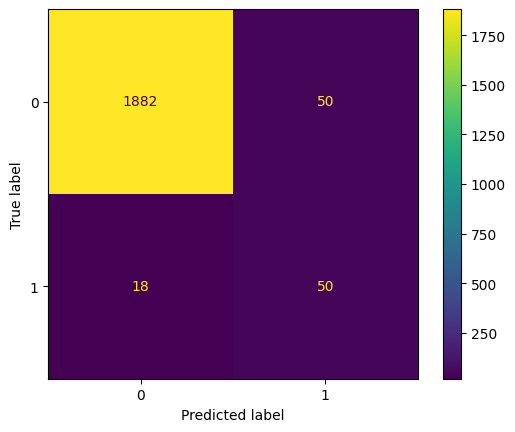

In [11]:
cm = confusion_matrix(
    y_test,
    preds
)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [12]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10)

Rotational speed [rpm]     0.234086
Torque [Nm]                0.187129
power_proxy                0.171755
Tool wear [min]            0.152924
temp_diff                  0.078725
Type_L                     0.053384
Air temperature [K]        0.052117
Process temperature [K]    0.041103
Type_M                     0.028777
dtype: float64